In [1]:
import csv
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt

In [2]:
EMBEDDING_DIM = 100
MAXLEN = 16
TRUNCATING = 'post'
PADDING = 'post'
OOV_TOKEN = "<OOV>"
MAX_EXAMPLES = 160000
TRAINING_SPLIT = 0.9

In [3]:
SENTIMENT_CSV = "training_cleaned.csv"

In [4]:
def parse_data_from_file(filename):    
    sentences = []
    labels = []
    with open(filename, 'r', encoding='latin-1') as csvfile:
        reader = csv.reader(csvfile, delimiter=",")     
        for row in reader:
            sentences.append(row[5])
            for_label = row[0]
            if for_label =="0":
                labels.append(0)
            else:
                labels.append(1)
    return sentences, labels

In [5]:
sentences, labels = parse_data_from_file(SENTIMENT_CSV)

In [6]:
sentences

["@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D",
 "is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!",
 '@Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds',
 'my whole body feels itchy and like its on fire ',
 "@nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. ",
 '@Kwesidei not the whole crew ',
 'Need a hug ',
 "@LOLTrish hey  long time no see! Yes.. Rains a bit ,only a bit  LOL , I'm fine thanks , how's you ?",
 "@Tatiana_K nope they didn't have it ",
 '@twittera que me muera ? ',
 "spring break in plain city... it's snowing ",
 'I just re-pierced my ears ',
 "@caregiving I couldn't bear to watch it.  And I thought the UA loss was embarrassing . . . . .",
 '@octolinz16 It it counts, idk why I did either. you never talk to me anymore ',
 "@smarrison i wo

In [7]:
sentences_and_labels = list(zip(sentences, labels))
random.seed(42)
sentences_and_labels = random.sample(sentences_and_labels, MAX_EXAMPLES)
sentences, labels = zip(*sentences_and_labels)

In [8]:
def train_val_split(sentences, labels, training_split):
    train_size = int(len(sentences)*training_split)
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]
    validation_sentences = sentences[train_size:]
    validation_labels = labels[train_size:]
    return train_sentences, validation_sentences, train_labels, validation_labels

In [9]:
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, labels, TRAINING_SPLIT)


In [10]:
def fit_tokenizer(train_sentences, oov_token):
    tokenizer = Tokenizer(num_words=len(train_sentences), oov_token="")
    tokenizer.fit_on_texts(train_sentences)
    return tokenizer

In [11]:
tokenizer = fit_tokenizer(train_sentences, OOV_TOKEN)
word_index = tokenizer.word_index
VOCAB_SIZE = len(word_index)


In [12]:
def seq_pad_and_trunc(sentences, tokenizer, padding, truncating, maxlen):
    sequences = tokenizer.texts_to_sequences(sentences)
    pad_trunc_sequences = pad_sequences(sequences, maxlen=maxlen, padding=padding, truncating=truncating)
    return pad_trunc_sequences

In [13]:
train_pad_trunc_seq = seq_pad_and_trunc(train_sentences, tokenizer, PADDING, TRUNCATING, MAXLEN)
val_pad_trunc_seq = seq_pad_and_trunc(val_sentences, tokenizer, PADDING, TRUNCATING, MAXLEN)

In [14]:
train_labels = np.array(train_labels)
val_labels = np.array(val_labels)

In [ ]:
GLOVE_FILE = 'glove.6B.100d.txt' #Se emplea el modelo GLOVE para obtener los embeddings de las palabras
GLOVE_EMBEDDINGS = {}
with open(GLOVE_FILE, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        GLOVE_EMBEDDINGS[word] = coefs

In [16]:
test_word = 'dog'

test_vector = GLOVE_EMBEDDINGS[test_word]

print(f"Representacion {test_word} Vector:\n\n{test_vector}")

Representacion dog Vector:

[ 0.30817    0.30938    0.52803   -0.92543   -0.73671    0.63475
  0.44197    0.10262   -0.09142   -0.56607   -0.5327     0.2013
  0.7704    -0.13983    0.13727    1.1128     0.89301   -0.17869
 -0.0019722  0.57289    0.59479    0.50428   -0.28991   -1.3491
  0.42756    1.2748    -1.1613    -0.41084    0.042804   0.54866
  0.18897    0.3759     0.58035    0.66975    0.81156    0.93864
 -0.51005   -0.070079   0.82819   -0.35346    0.21086   -0.24412
 -0.16554   -0.78358   -0.48482    0.38968   -0.86356   -0.016391
  0.31984   -0.49246   -0.069363   0.018869  -0.098286   1.3126
 -0.12116   -1.2399    -0.091429   0.35294    0.64645    0.089642
  0.70294    1.1244     0.38639    0.52084    0.98787    0.79952
 -0.34625    0.14095    0.80167    0.20987   -0.86007   -0.15308
  0.074523   0.40816    0.019208   0.51587   -0.34428   -0.24525
 -0.77984    0.27425    0.22418    0.20164    0.017431  -0.014697
 -1.0235    -0.39695   -0.0056188  0.30569    0.31748    0.021

In [17]:
print(f"Cada palabra tiene la forma: {test_vector.shape}")

Cada palabra tiene la forma: (100,)


In [18]:
EMBEDDINGS_MATRIX = np.zeros((VOCAB_SIZE+1, EMBEDDING_DIM))
for word, i in word_index.items():
    embedding_vector = GLOVE_EMBEDDINGS.get(word)
    if embedding_vector is not None:
        EMBEDDINGS_MATRIX[i] = embedding_vector

In [ ]:
def create_model(vocab_size, embedding_dim, maxlen, embeddings_matrix):
    model = tf.keras.Sequential([ 
        tf.keras.layers.Embedding(vocab_size+1, embedding_dim, input_length=maxlen, weights=[embeddings_matrix], trainable=False), #+1 porque se agrega el ovv_token, embedding_dim es el numero de dimensiones del embedding, input_length es el numero de palabras que tiene la sentencia, weights es la matriz de embeddings, trainable=False es para que no se actualice durante el entrenamiento. Está usando los modelos preentrenados de GLOVE.
        # Las siguientes capas son las que permiten que el modelo aprenda las palabras que no están en el modelo preentrenado de GLOVE.
        tf.keras.layers.Dropout(0.2), #permite evitar el sobreajuste
        tf.keras.layers.Conv1D(64, 5, activation='relu'), #Conv1D es una capa de convolucion 1D, 64 es el numero de filtros, 5 es el tamano de la ventana de la convolucion, activation es la funcion de activacion. Se puede emplear convoluciones 1D, 2D, 3D. 3D es empleado para videos, 2D para imagenes, 1D para texto. En este caso la convolucion permite reconocer patrones de texto, como por ejemplo aquellas palabras que tienen un sentimiento negativo, están juntas, etc.
        tf.keras.layers.MaxPooling1D(pool_size=4), #permite reducir el tamano de la matriz de salida de la convolucion. pool_size es el tamano de la ventana de la pool.
        tf.keras.layers.LSTM(64), #LSTM es el modelo de memoria, 64 es el numero de neuronas, input_shape es el numero de palabras que tiene la sentencia, no necesariamente corresponde a Conv1D(64, 5..)
        tf.keras.layers.Dense(1, activation='sigmoid') #Dense es una capa densa, 1 es el numero de neuronas, activation es la funcion de activacion
    ])
    
    model.compile(loss='binary_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy']) 

    return model

In [20]:
model = create_model(VOCAB_SIZE, EMBEDDING_DIM, MAXLEN, EMBEDDINGS_MATRIX)
history = model.fit(train_pad_trunc_seq, train_labels, epochs=20, validation_data=(val_pad_trunc_seq, val_labels))

Epoch 1/20


/Users/larenwell/Documents/personal/projects/ai-dl-tensorflow-specialization-fabricum-pucp/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


4500/4500 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.6993 - loss: 0.5670 - val_accuracy: 0.7367 - val_loss: 0.5229
Epoch 2/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7302 - loss: 0.5287 - val_accuracy: 0.7453 - val_loss: 0.5096
Epoch 3/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7428 - loss: 0.5124 - val_accuracy: 0.7430 - val_loss: 0.5142
Epoch 4/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7499 - loss: 0.5009 - val_accuracy: 0.7516 - val_loss: 0.5008
Epoch 5/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7554 - loss: 0.4940 - val_accuracy: 0.7424 - val_loss: 0.5188
Epoch 6/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7602 - loss: 0.4855 - val_accuracy: 0.7567 - val_loss: 0.4995
Epoch 7/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7638 - loss: 0.4797 - val_accuracy: 0.7551 - val_loss: 0.4991
Epoch 8/20
4500/4500 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7670 - loss: 0.4749 - val_accurac

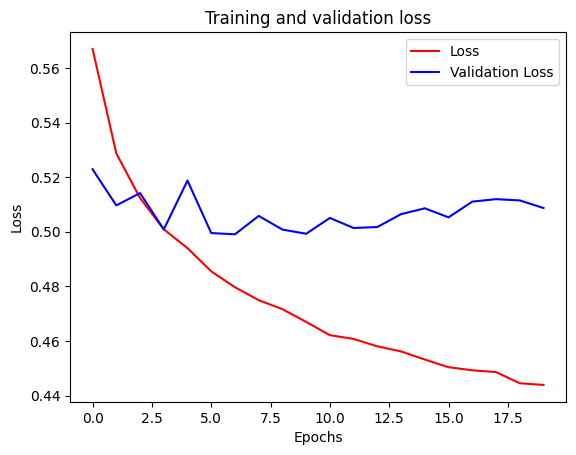

In [21]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = [*range(20)]
plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.title('Training and validation loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["Loss", "Validation Loss"])
plt.show()

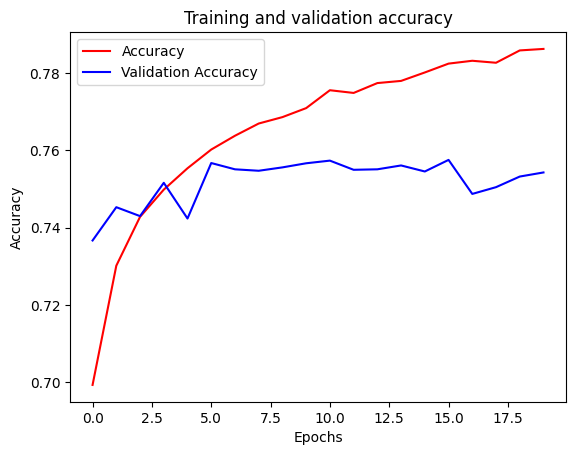

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Accuracy", "Validation Accuracy"])
plt.show()

In [23]:
def predict_tweet(text, model, tokenizer, maxlen):
    sequence = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(sequence, maxlen=maxlen, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]
    if prediction >= 0.5:
        sentiment = "POSITIVE 😄"
    else:
        sentiment = "NEGATIVE 😡"
    
    print(f"Tweet: {text}")
    print(f"Score: {prediction:.4f}")
    print(f"Sentimiento: {sentiment}")

In [24]:
predict_tweet("i love this movie so much", model, tokenizer, MAXLEN)
predict_tweet("this is the worst thing ever", model, tokenizer, MAXLEN)
predict_tweet("i dont like this at all", model, tokenizer, MAXLEN)
predict_tweet("this is okay not bad", model, tokenizer, MAXLEN)

Tweet: i love this movie so much
Score: 0.9411
Sentimiento: POSITIVE 😄
Tweet: this is the worst thing ever
Score: 0.0138
Sentimiento: NEGATIVE 😡
Tweet: i dont like this at all
Score: 0.0693
Sentimiento: NEGATIVE 😡
Tweet: this is okay not bad
Score: 0.0476
Sentimiento: NEGATIVE 😡


In [25]:
predict_tweet("it was a good movie", model, tokenizer, MAXLEN)

Tweet: it was a good movie
Score: 0.9909
Sentimiento: POSITIVE 😄
